# 03 — Spatial patterns

**Purpose:** Visualize HH and LL clusters, examine distribution of HH frequency across seeds, and run connected-component analysis for hotspot stability. Observation-level cross-seed stability requires a fixed test set across runs.

## Imports and path setup

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from analysis.experiment_runner import _get_run_dirs
from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import (
    load_meta,
    load_P_test,
    load_split,
    run_spatial,
    select_rashomon_global,
    mean_variance,
    pointwise_variance,
    pointwise_conflict,
)
from scipy.sparse.csgraph import connected_components as sparse_connected_components
from analysis.spatial import extract_hh_components
from analysis.stability import hh_selection_frequency, hh_jaccard_matrix, summarize_hh_stability

RESULTS_DEFAULT_DIR = RAW_RESULTS
RESULTS_FIXED_TEST_DIR = ROOT / "results_fixed_test"
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb03")

## All datasets: compute HH masks across seeds

For each dataset and run we compute spatial analysis (Moran's I, LISA) and collect HH_mask, LL_mask, and pointwise variance.

In [2]:
DATASET = "compas"
K = 25
k_nn = K_NN_BY_DATASET[DATASET]
USE_FIXED_TEST = True  # Required for valid observation-level cross-seed stability.

RESULTS_DIR = RESULTS_FIXED_TEST_DIR if USE_FIXED_TEST else RESULTS_DEFAULT_DIR
dataset_dir = RESULTS_DIR / DATASET
run_dirs = _get_run_dirs(dataset_dir)
if not run_dirs:
    raise SystemExit(f"No runs found in {dataset_dir}. "
                     f"Run fixed-test training first: run_training_pipeline_fixed_test.py")

spatial_by_run = []
test_idx_ref = None
test_indices_aligned = True

for run_dir in run_dirs:
    split = load_split(run_dir)
    test_idx = np.asarray(split["test"], dtype=int)

    if test_idx_ref is None:
        test_idx_ref = test_idx
    elif not np.array_equal(test_idx_ref, test_idx):
        test_indices_aligned = False

    n_cand = len(load_meta(run_dir))
    K_actual = min(K, n_cand)
    X_test = get_transformed_test_features(run_dir, DATASET)
    res = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
    res["run_dir"] = run_dir.name
    res["test_idx"] = test_idx

    P_test = load_P_test(run_dir)
    idx = select_rashomon_global(run_dir, K=K_actual)
    res["mean_variance"] = mean_variance(P_test[idx], ddof=0)
    spatial_by_run.append(res)

print(f"Computed spatial metrics for {len(spatial_by_run)} runs.")
print(f"Test indices aligned across runs: {test_indices_aligned}")

if not test_indices_aligned:
    raise ValueError(
        "Observation-level HH stability is invalid because test sets differ across runs. "
        "Use fixed-test artifacts (results_fixed_test/...)."
    )

Computed spatial metrics for 10 runs.
Test indices aligned across runs: True


## HH stability analysis and visualizations

Compute HH selection frequency across seeds, Jaccard overlap matrix, stability summary, and save figures (frequency scatter, Jaccard heatmap, HH location in feature space) plus component summary table.

Representative run (median HH count): index=2, run=seed=2, n_HH=81


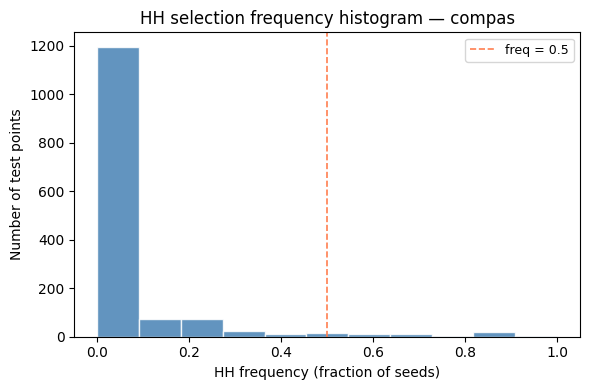

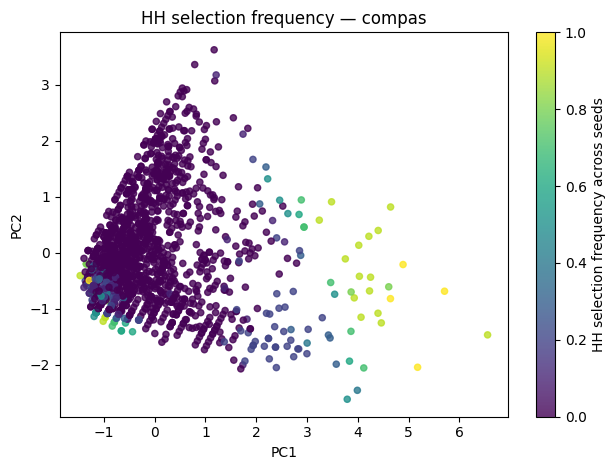

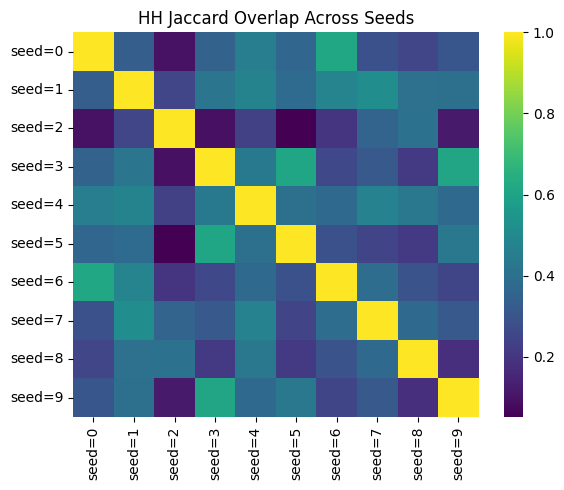

,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard
0,seed=0,3,81,0.056133,0.339483,0.052174,0.617647
1,seed=1,4,28,0.056133,0.339483,0.052174,0.617647
2,seed=2,3,32,0.056133,0.339483,0.052174,0.617647
3,seed=3,1,33,0.056133,0.339483,0.052174,0.617647
4,seed=4,5,41,0.056133,0.339483,0.052174,0.617647
5,seed=5,1,36,0.056133,0.339483,0.052174,0.617647
6,seed=6,4,70,0.056133,0.339483,0.052174,0.617647
7,seed=7,6,31,0.056133,0.339483,0.052174,0.617647
8,seed=8,5,60,0.056133,0.339483,0.052174,0.617647
9,seed=9,3,26,0.056133,0.339483,0.052174,0.617647


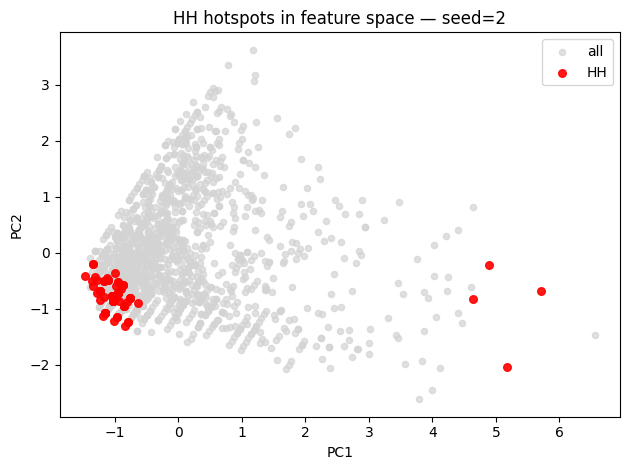

In [3]:
# Part 1: HH stability
hh_masks = [r["HH_mask"] for r in spatial_by_run]
freq = hh_selection_frequency(hh_masks)
J = hh_jaccard_matrix(hh_masks)
stability_summary = summarize_hh_stability(hh_masks)

# X_test from first run for plotting (same test size across runs)
run_dir0 = run_dirs[0]
X_test = get_transformed_test_features(run_dir0, DATASET)
if hasattr(X_test, "values"):
    X_plot = np.asarray(X_test.values, dtype=float)
else:
    X_plot = np.asarray(X_test, dtype=float)
n_features = X_plot.shape[1]

if n_features == 2:
    coords = X_plot
elif n_features == 1:
    coords = np.column_stack([X_plot.ravel(), np.zeros(X_plot.shape[0])])
else:
    pca = PCA(n_components=2).fit(X_plot)
    coords = pca.transform(X_plot)

# --- Representative run selection (median HH count) ---
n_hh_counts = np.array([int(np.sum(r["HH_mask"])) for r in spatial_by_run])
median_hh = np.median(n_hh_counts)
rep_idx = int(np.argmin(np.abs(n_hh_counts - median_hh)))
print(f"Representative run (median HH count): index={rep_idx}, "
      f"run={spatial_by_run[rep_idx]['run_dir']}, n_HH={n_hh_counts[rep_idx]}")

# Part 2A-hist: HH frequency histogram
fig_hist, ax_hist = plt.subplots(figsize=(6, 4))
ax_hist.hist(freq, bins=np.linspace(0, 1, 12), color="steelblue", edgecolor="white", alpha=0.85)
ax_hist.set_xlabel("HH frequency (fraction of seeds)")
ax_hist.set_ylabel("Number of test points")
ax_hist.set_title(f"HH selection frequency histogram — {DATASET}")
ax_hist.axvline(0.5, color="coral", ls="--", lw=1.2, label="freq = 0.5")
ax_hist.legend(fontsize=9)
fig_hist.tight_layout()
fig_hist.savefig(FIG_DIR / f"hh_freq_histogram_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Part 2A: HH frequency visualization
plt.figure()
sc = plt.scatter(coords[:, 0], coords[:, 1], c=freq, cmap="viridis", s=20, alpha=0.8)
plt.colorbar(sc, label="HH selection frequency across seeds")
plt.xlabel("PC1" if n_features > 2 else "Feature 1")
plt.ylabel("PC2" if n_features > 2 else "Feature 2")
plt.title(f"HH selection frequency — {DATASET}")
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_stability_freq_{DATASET}.pdf")
plt.show()

# Part 2B: Jaccard heatmap
run_labels = [r["run_dir"] for r in spatial_by_run]
plt.figure(figsize=(6, 5))
sns.heatmap(J, xticklabels=run_labels, yticklabels=run_labels, annot=False, cmap="viridis")
plt.title("HH Jaccard Overlap Across Seeds")
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_jaccard_heatmap_{DATASET}.pdf")
plt.show()

# Part 3: Component summary + stability metrics
component_stats = []
for r in spatial_by_run:
    lisa_df = pd.DataFrame({"cluster": np.where(r["HH_mask"], "HH", "NS")})
    W = r["W"].to_sparse() if hasattr(r["W"], "to_sparse") else r["W"].sparse
    _, components = extract_hh_components(lisa_df, W, min_size=5)
    n_comp = len(components)
    max_size = max(len(inds) for inds in components.values()) if components else 0
    component_stats.append({"run": r["run_dir"], "n_components": n_comp, "max_component_size": max_size})

hh_component_summary = pd.DataFrame(component_stats)
for k, v in stability_summary.items():
    hh_component_summary[k] = v
hh_component_summary.to_csv(TABLE_DIR / f"hh_component_summary_{DATASET}.csv", index=False)
display(hh_component_summary)

# Part 4: HH location in feature space (representative run)
r0 = spatial_by_run[rep_idx]
HH_mask_rep = r0["HH_mask"]
plt.figure()
plt.scatter(coords[~HH_mask_rep, 0], coords[~HH_mask_rep, 1], c="lightgray", s=20, alpha=0.7, label="all")
plt.scatter(coords[HH_mask_rep, 0], coords[HH_mask_rep, 1], c="red", s=30, alpha=0.9, label="HH")
plt.xlabel("PC1" if n_features > 2 else "Feature 1")
plt.ylabel("PC2" if n_features > 2 else "Feature 2")
plt.title(f"HH hotspots in feature space — {r0['run_dir']}")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_location_{DATASET}.pdf")
plt.show()

## Stability: HH count and variance summary per run

Plot number of HH points and mean pointwise variance per run to assess stability across seeds.

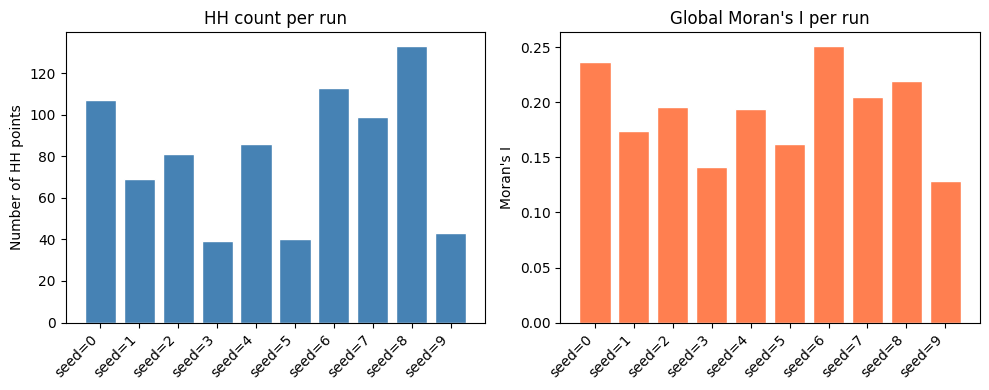

In [4]:
n_hh_per_run = [int(np.sum(r["HH_mask"])) for r in spatial_by_run]
run_labels = [r["run_dir"] for r in spatial_by_run]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(range(len(n_hh_per_run)), n_hh_per_run, color="steelblue", edgecolor="white")
ax1.set_xticks(range(len(run_labels)))
ax1.set_xticklabels(run_labels, rotation=45, ha="right")
ax1.set_ylabel("Number of HH points")
ax1.set_title("HH count per run")

moran_per_run = [r["moran_i"] for r in spatial_by_run]
ax2.bar(range(len(moran_per_run)), moran_per_run, color="coral", edgecolor="white")
ax2.set_xticks(range(len(run_labels)))
ax2.set_xticklabels(run_labels, rotation=45, ha="right")
ax2.set_ylabel("Moran's I")
ax2.set_title("Global Moran's I per run")
plt.tight_layout()
fig.savefig(FIG_DIR / f"hh_moran_per_run_{DATASET}.pdf", bbox_inches="tight")
plt.show()

## Correlation: mean variance vs Moran's I per run

Plot mean variance (multiplicity) against global Moran's I (spatial clustering of variance) across runs.

- **Positive correlation:** More multiplicity → stronger spatial clustering of disagreement. Multiplicity concentrates in regions rather than being diffuse.
- **No (or weak) correlation:** Spatial structure of hotspots can exist even when overall multiplicity is small; the two are not simply coupled.

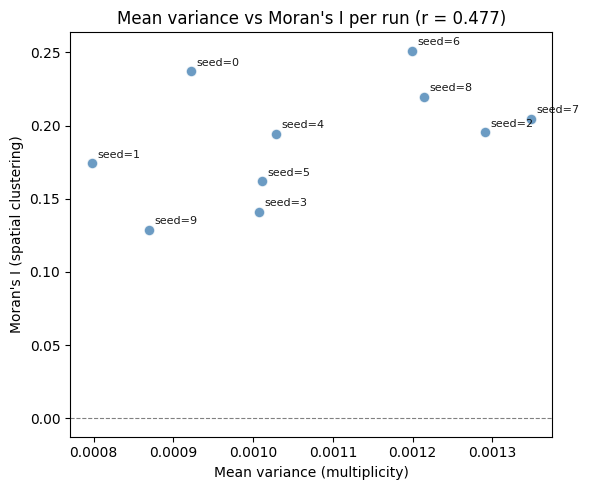

→ Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.


In [5]:
corr_df = pd.DataFrame({
    "run": [r["run_dir"] for r in spatial_by_run],
    "mean_variance": [r["mean_variance"] for r in spatial_by_run],
    "moran_i": [r["moran_i"] for r in spatial_by_run],
})
r_pearson = np.corrcoef(corr_df["mean_variance"], corr_df["moran_i"])[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(corr_df["mean_variance"], corr_df["moran_i"], s=60, alpha=0.8, color="steelblue", edgecolor="white")
for _, row in corr_df.iterrows():
    ax.annotate(row["run"], (row["mean_variance"], row["moran_i"]), fontsize=8, alpha=0.9, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Mean variance (multiplicity)")
ax.set_ylabel("Moran's I (spatial clustering)")
ax.set_title(f"Mean variance vs Moran's I per run (r = {r_pearson:.3f})")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
fig.savefig(FIG_DIR / f"variance_vs_moran_{DATASET}.pdf", bbox_inches="tight")
plt.show()

if r_pearson > 0.2:
    print("→ Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.")
elif r_pearson < -0.2:
    print("→ Negative correlation: higher multiplicity tends to go with weaker spatial clustering.")
else:
    print("→ Weak or no correlation: spatial structure of hotspots can exist even when overall multiplicity is small.")

## Connected component analysis (hotspot regions)

For one run, extract HH connected components using the kNN graph and report region sizes. Uses `analysis.spatial.extract_hh_components`. The same W (from spatial_analysis) is used; kNN is directed. For undirected region connectivity you could symmetrize W before extraction.

In [6]:
# Use representative run for component analysis
r0 = spatial_by_run[rep_idx]
HH_mask = r0["HH_mask"]
W_pysal = r0["W"]
W_sparse = W_pysal.to_sparse() if hasattr(W_pysal, "to_sparse") else W_pysal.sparse

lisa_df = pd.DataFrame({
    "cluster": np.where(HH_mask, "HH", "NS"),
})
comp_id, components = extract_hh_components(lisa_df, W_sparse, min_size=5)

print(f"Run: {r0['run_dir']}")
print(f"HH points: {HH_mask.sum()}")
print(f"Connected components (min_size=5): {len(components)}")
for cid, inds in components.items():
    print(f"  Component {cid}: n = {len(inds)}")

Run: seed=2
HH points: 81
Connected components (min_size=5): 3
  Component 0: n = 32
  Component 1: n = 23
  Component 2: n = 20


## Region persistence summary

Across runs, summarize number of HH components and largest component size (when available) to assess hotspot stability.

In [7]:
# Component summary (with stability metrics) was computed and saved in the HH stability cell above.
# Saved to: tables/hh_component_summary_{DATASET}.csv
print("HH component summary (min_size=5) with stability metrics:")
display(hh_component_summary)
print(f"Mean n_components: {hh_component_summary['n_components'].mean():.2f}")
print(f"Mean max_component_size: {hh_component_summary['max_component_size'].mean():.2f}")

HH component summary (min_size=5) with stability metrics:


,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard
0,seed=0,3,81,0.056133,0.339483,0.052174,0.617647
1,seed=1,4,28,0.056133,0.339483,0.052174,0.617647
2,seed=2,3,32,0.056133,0.339483,0.052174,0.617647
3,seed=3,1,33,0.056133,0.339483,0.052174,0.617647
4,seed=4,5,41,0.056133,0.339483,0.052174,0.617647
5,seed=5,1,36,0.056133,0.339483,0.052174,0.617647
6,seed=6,4,70,0.056133,0.339483,0.052174,0.617647
7,seed=7,6,31,0.056133,0.339483,0.052174,0.617647
8,seed=8,5,60,0.056133,0.339483,0.052174,0.617647
9,seed=9,3,26,0.056133,0.339483,0.052174,0.617647


Mean n_components: 3.50
Mean max_component_size: 43.80


## Graph connectivity diagnostics

After constructing the kNN weights/graph W for X_test, compute the number of connected components and the largest component size. The kNN graph from PySAL is directed; we symmetrize it for the undirected connectivity check.

In [8]:
# Graph connectivity diagnostic using the representative run's kNN weights
W_rep = spatial_by_run[rep_idx]["W"]
W_sparse_rep = W_rep.to_sparse() if hasattr(W_rep, "to_sparse") else W_rep.sparse

# Symmetrize for undirected connectivity
W_sym = W_sparse_rep + W_sparse_rep.T
W_sym = (W_sym > 0).astype(int)

n_components, labels = sparse_connected_components(W_sym, directed=False)
component_sizes = np.bincount(labels)
largest_component = int(component_sizes.max())
n_test = W_sym.shape[0]

print(f"Graph connectivity diagnostics (run: {spatial_by_run[rep_idx]['run_dir']}, k={k_nn}):")
print(f"  kNN graph symmetrized to undirected for connectivity check")
print(f"  Number of connected components: {n_components}")
print(f"  Largest component size: {largest_component} ({largest_component/n_test:.1%} of {n_test} test points)")
if n_components > 1:
    print(f"  Component size distribution: {sorted(component_sizes, reverse=True)}")
else:
    print(f"  Graph is fully connected.")

Graph connectivity diagnostics (run: seed=2, k=30):
  kNN graph symmetrized to undirected for connectivity check
  Number of connected components: 1
  Largest component size: 1443 (100.0% of 1443 test points)
  Graph is fully connected.


## HH hotspot reproducibility across runs

Goal: Test whether HH hotspots are reproducible across random splits/seeds (not Monte-Carlo noise).

- **Stable point ID:** Original dataset row index from the split (test indices) so the same row is comparable across runs.
- **(1) Point-level:** Per-point HH frequency across runs; histogram and fraction of points with freq ≥ 0.8, ≥ 0.5.
- **(2) Region-level:** HH connected components per run (same kNN graph); compare regions via Jaccard overlap and region persistence (how often a similar component reappears).
- **(3) Summary:** Mean ± std over runs: n_HH, n_components, max component size, total HH mass (sum of variance over HH points).

In [9]:
# Build per-run data with stable point IDs (original dataset row index from split)
from collections import defaultdict

n_cand = len(load_meta(run_dirs[0]))
K_actual = min(K, n_cand)

run_data = []
for r in spatial_by_run:
    run_dir = dataset_dir / r["run_dir"]
    split = load_split(run_dir)
    test_idx = split["test"]  # stable IDs: original row indices in the dataset
    HH_mask = r["HH_mask"]
    # Pointwise variance for this run (for total HH mass)
    P_test = load_P_test(run_dir)
    idx = select_rashomon_global(run_dir, K=K_actual)
    v = pointwise_variance(P_test[idx], ddof=0)
    # Components: map to stable IDs
    lisa_df = pd.DataFrame({"cluster": np.where(HH_mask, "HH", "NS")})
    W = r["W"].to_sparse() if hasattr(r["W"], "to_sparse") else r["W"].sparse
    _, components = extract_hh_components(lisa_df, W, min_size=5)
    comp_stable = {
        cid: set(int(test_idx[i]) for i in inds)
        for cid, inds in components.items()
    }
    run_data.append({
        "run_dir": r["run_dir"],
        "test_idx": test_idx,
        "HH_mask": HH_mask,
        "v": v,
        "n_HH": int(np.sum(HH_mask)),
        "components": components,
        "comp_stable": comp_stable,
        "n_components": len(components),
        "max_component_size": max(len(inds) for inds in components.values()) if components else 0,
        "total_HH_mass": float(np.sum(v[HH_mask])),
    })

### (1) Point-level stability: How often is point x in HH?

Per-point HH frequency = (number of runs where point was in test and was HH) / (number of runs where point was in test). Histogram and fraction of points with freq ≥ 0.8, ≥ 0.5.

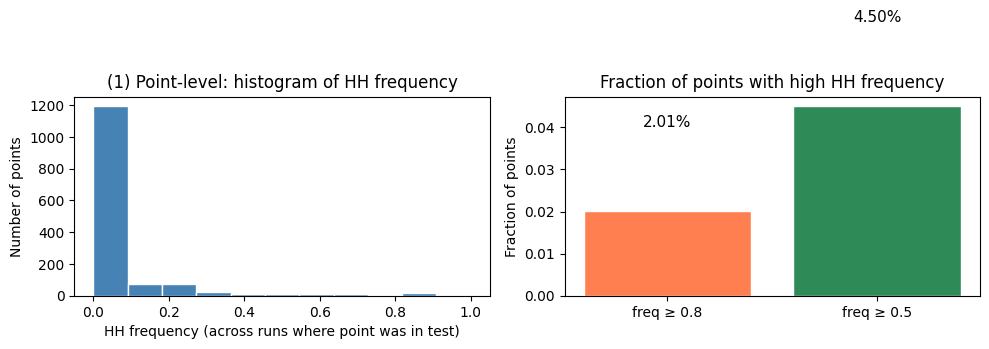

Fraction of points with HH freq ≥ 0.8: 2.01%
Fraction of points with HH freq ≥ 0.5: 4.50%


In [10]:
# (1) Point-level HH frequency (stable_id = original dataset row index)
stable_id_to_hh = defaultdict(list)  # stable_id -> list of 0/1 (HH in that run)
for rd in run_data:
    for i, sid in enumerate(rd["test_idx"]):
        stable_id_to_hh[int(sid)].append(1 if rd["HH_mask"][i] else 0)

hh_freq = {}
for sid, hh_list in stable_id_to_hh.items():
    hh_freq[sid] = np.mean(hh_list)

freq_values = np.array(list(hh_freq.values()))
n_runs = len(run_dirs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(freq_values, bins=np.linspace(0, 1, 12), color="steelblue", edgecolor="white")
ax1.set_xlabel("HH frequency (across runs where point was in test)")
ax1.set_ylabel("Number of points")
ax1.set_title("(1) Point-level: histogram of HH frequency")

frac_80 = np.mean(freq_values >= 0.8)
frac_50 = np.mean(freq_values >= 0.5)
ax2.bar(["freq ≥ 0.8", "freq ≥ 0.5"], [frac_80, frac_50], color=["coral", "seagreen"], edgecolor="white")
ax2.set_ylabel("Fraction of points")
ax2.set_title("Fraction of points with high HH frequency")
for i, (lbl, val) in enumerate([("≥0.8", frac_80), ("≥0.5", frac_50)]):
    ax2.text(i, val + 0.02, f"{val:.2%}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()
print(f"Fraction of points with HH freq ≥ 0.8: {frac_80:.2%}")
print(f"Fraction of points with HH freq ≥ 0.5: {frac_50:.2%}")

### (2) Region-level stability: Jaccard overlap and region persistence

For each run, HH components are sets of stable IDs. Compare across runs: Jaccard(A,B) = |A∩B|/|A∪B|. For each component in a run, find best-matching component in another run (max Jaccard). **Region persistence:** fraction of other runs that have at least one component with Jaccard > 0.3 to this one.

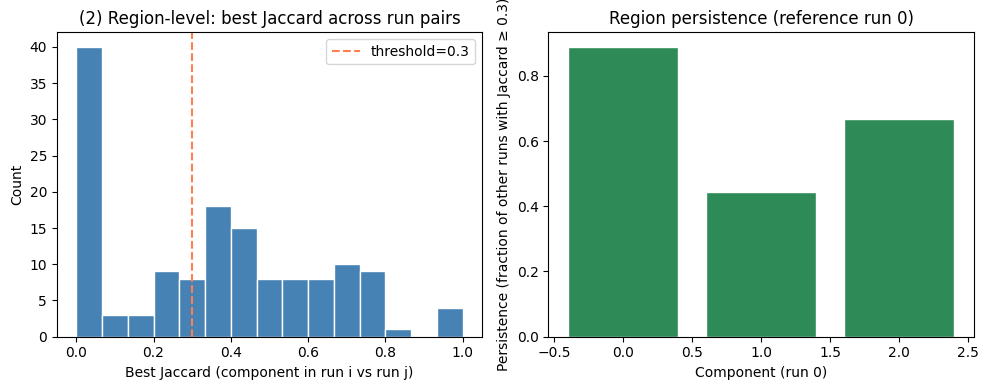

Mean best Jaccard across run pairs: 0.349 ± 0.280
Mean region persistence (run 0): 66.67%


In [11]:
# (2) Region-level: Jaccard between component node sets, region persistence
def jaccard(A, B):
    if len(A) == 0 and len(B) == 0:
        return 1.0
    inter = len(A & B)
    union = len(A | B)
    return inter / union if union else 0.0

JACCARD_THRESHOLD = 0.3
run_pairs = [(i, j) for i in range(len(run_data)) for j in range(len(run_data)) if i < j]
best_jaccards = []  # one per (run_i, run_j, comp in i): best Jaccard to any comp in j
for i, j in run_pairs:
    for cid, A in run_data[i]["comp_stable"].items():
        best = max(
            (jaccard(A, B) for B in run_data[j]["comp_stable"].values()),
            default=0.0,
        )
        best_jaccards.append(best)

# Region persistence: for each component in run 0, in how many other runs does a comp match (Jaccard > thresh)?
ref_run = 0
persistence = []
for cid, A in run_data[ref_run]["comp_stable"].items():
    count = 0
    for other in range(len(run_data)):
        if other == ref_run:
            continue
        best = max(
            (jaccard(A, B) for B in run_data[other]["comp_stable"].values()),
            default=0.0,
        )
        if best >= JACCARD_THRESHOLD:
            count += 1
    persistence.append(count / (len(run_data) - 1) if len(run_data) > 1 else 0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(best_jaccards, bins=np.linspace(0, 1, 16), color="steelblue", edgecolor="white")
ax1.axvline(JACCARD_THRESHOLD, color="coral", linestyle="--", label=f"threshold={JACCARD_THRESHOLD}")
ax1.set_xlabel("Best Jaccard (component in run i vs run j)")
ax1.set_ylabel("Count")
ax1.set_title("(2) Region-level: best Jaccard across run pairs")
ax1.legend()

ax2.bar(range(len(persistence)), persistence, color="seagreen", edgecolor="white")
ax2.set_ylabel("Persistence (fraction of other runs with Jaccard ≥ 0.3)")
ax2.set_xlabel("Component (run 0)")
ax2.set_title("Region persistence (reference run 0)")
plt.tight_layout()
plt.show()
print(f"Mean best Jaccard across run pairs: {np.mean(best_jaccards):.3f} ± {np.std(best_jaccards):.3f}")
print(f"Mean region persistence (run 0): {np.mean(persistence):.2%}" if persistence else "No components in run 0.")

### (3) Summary stability statistics (mean ± std over runs)

Per run: number of HH points, number of HH components, size of largest HH component, total HH mass (sum of pointwise variance over HH points).

In [12]:
# (3) Summary stability statistics
summary_df = pd.DataFrame([
    {
        "run": rd["run_dir"],
        "n_HH": rd["n_HH"],
        "n_components": rd["n_components"],
        "max_component_size": rd["max_component_size"],
        "total_HH_mass": rd["total_HH_mass"],
    }
    for rd in run_data
])
stats = {
    "n_HH": (summary_df["n_HH"].mean(), summary_df["n_HH"].std()),
    "n_components": (summary_df["n_components"].mean(), summary_df["n_components"].std()),
    "max_component_size": (summary_df["max_component_size"].mean(), summary_df["max_component_size"].std()),
    "total_HH_mass": (summary_df["total_HH_mass"].mean(), summary_df["total_HH_mass"].std()),
}
report = pd.DataFrame([
    {"metric": k, "mean": v[0], "std": v[1], "mean ± std": f"{v[0]:.2f} ± {v[1]:.2f}"}
    for k, v in stats.items()
])
print("(3) Summary stability (mean ± std over runs):")
display(report)
display(summary_df)

(3) Summary stability (mean ± std over runs):


,metric,mean,std,mean ± std
0,n_HH,81.00000,32.974738,81.00 ± 32.97
1,n_components,3.50000,1.649916,3.50 ± 1.65
2,max_component_size,43.80000,19.401031,43.80 ± 19.40
3,total_HH_mass,0.34263,0.135689,0.34 ± 0.14


,run,n_HH,n_components,max_component_size,total_HH_mass
0,seed=0,107,3,81,0.309301
1,seed=1,69,4,28,0.229724
2,seed=2,81,3,32,0.520607
3,seed=3,39,1,33,0.180253
4,seed=4,86,5,41,0.288552
5,seed=5,40,1,36,0.259140
6,seed=6,113,4,70,0.437025
7,seed=7,99,6,31,0.526163
8,seed=8,133,5,60,0.481412
9,seed=9,43,3,26,0.194128


## Getis-Ord Gi* hotspot comparison

Use Getis-Ord Gi* as an alternative hotspot detector to LISA.  
Gi* focuses more directly on concentrations of high values, while LISA mixes cluster and outlier structure.  
This comparison shows whether the main hotspot region is robust to the specific local statistic.

Run: seed=2
LISA HH count: 43
Gi* hotspot count: 97
Intersection: 9
Union: 131
Jaccard(LISA HH, Gi* hotspot): 0.0687


,Gi_star,p_value,significant,hotspot,lisa_hh,overlap
0,-0.407603,0.406,False,False,False,False
1,-0.429140,0.367,False,False,False,False
2,-0.153956,0.805,False,False,False,False
3,-0.716213,0.100,False,False,False,False
4,0.117830,0.853,False,False,False,False


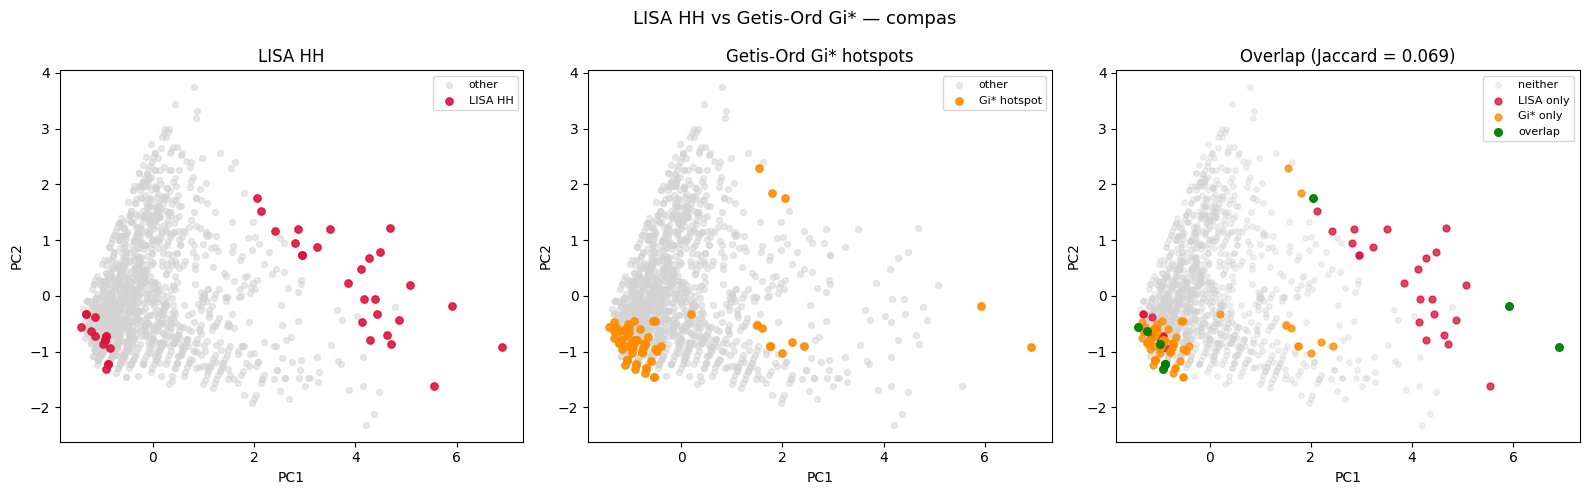

,group,count,mean_variance
0,LISA HH,43,0.003472
1,Gi* hotspot,97,0.007193
2,Overlap,9,0.011292


In [13]:
from analysis.spatial import getis_ord_gi_star
from sklearn.decomposition import PCA

# Reconstruct pointwise variance for the same representative run
run_dir_rep = run_dirs[rep_idx]
idx_rep = select_rashomon_global(run_dir_rep, K=K)
P_test_rep = load_P_test(run_dir_rep)
v_rep = pointwise_variance(P_test_rep[idx_rep], ddof=0)

# Run Gi* on the same spatial weights used for LISA/component analysis
gi_df = getis_ord_gi_star(
    v_rep,
    W_sparse,
    permutations=999,
    alpha=0.05,
    fdr=False,
    seed=42,
)

gi_hot = gi_df["hotspot"].to_numpy()

# Coordinates for visualization
X_test_rep = get_transformed_test_features(run_dir_rep, DATASET)
if hasattr(X_test_rep, "values"):
    X_rep = np.asarray(X_test_rep.values, dtype=float)
else:
    X_rep = np.asarray(X_test_rep, dtype=float)

if X_rep.shape[1] == 2:
    coords_rep = X_rep
elif X_rep.shape[1] == 1:
    coords_rep = np.column_stack([X_rep.ravel(), np.zeros(X_rep.shape[0])])
else:
    coords_rep = PCA(n_components=2, random_state=42).fit_transform(X_rep)

# Compare LISA-HH vs Gi* hotspots
lisa_hh = HH_mask
overlap = lisa_hh & gi_hot
lisa_only = lisa_hh & ~gi_hot
gi_only = gi_hot & ~lisa_hh
neither = ~(lisa_hh | gi_hot)

union = np.sum(lisa_hh | gi_hot)
intersection = np.sum(overlap)
jaccard = intersection / union if union > 0 else np.nan

print(f"Run: {r0['run_dir']}")
print(f"LISA HH count: {int(lisa_hh.sum())}")
print(f"Gi* hotspot count: {int(gi_hot.sum())}")
print(f"Intersection: {int(intersection)}")
print(f"Union: {int(union)}")
print(f"Jaccard(LISA HH, Gi* hotspot): {jaccard:.4f}")

display(
    gi_df.assign(
        lisa_hh=lisa_hh,
        overlap=overlap,
    ).head()
)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: LISA HH
axes[0].scatter(
    coords_rep[~lisa_hh, 0], coords_rep[~lisa_hh, 1],
    c="lightgray", s=18, alpha=0.5, label="other"
)
axes[0].scatter(
    coords_rep[lisa_hh, 0], coords_rep[lisa_hh, 1],
    c="crimson", s=28, alpha=0.9, label="LISA HH"
)
axes[0].set_title("LISA HH")
axes[0].set_xlabel("PC1" if X_rep.shape[1] > 2 else "Feature 1")
axes[0].set_ylabel("PC2" if X_rep.shape[1] > 2 else "Feature 2")
axes[0].legend(fontsize=8)

# Panel 2: Gi* hotspots
axes[1].scatter(
    coords_rep[~gi_hot, 0], coords_rep[~gi_hot, 1],
    c="lightgray", s=18, alpha=0.5, label="other"
)
axes[1].scatter(
    coords_rep[gi_hot, 0], coords_rep[gi_hot, 1],
    c="darkorange", s=28, alpha=0.9, label="Gi* hotspot"
)
axes[1].set_title("Getis-Ord Gi* hotspots")
axes[1].set_xlabel("PC1" if X_rep.shape[1] > 2 else "Feature 1")
axes[1].set_ylabel("PC2" if X_rep.shape[1] > 2 else "Feature 2")
axes[1].legend(fontsize=8)

# Panel 3: overlap
axes[2].scatter(
    coords_rep[neither, 0], coords_rep[neither, 1],
    c="lightgray", s=15, alpha=0.35, label="neither"
)
axes[2].scatter(
    coords_rep[lisa_only, 0], coords_rep[lisa_only, 1],
    c="crimson", s=24, alpha=0.8, label="LISA only"
)
axes[2].scatter(
    coords_rep[gi_only, 0], coords_rep[gi_only, 1],
    c="darkorange", s=24, alpha=0.8, label="Gi* only"
)
axes[2].scatter(
    coords_rep[overlap, 0], coords_rep[overlap, 1],
    c="green", s=30, alpha=0.95, label="overlap"
)
axes[2].set_title(f"Overlap (Jaccard = {jaccard:.3f})")
axes[2].set_xlabel("PC1" if X_rep.shape[1] > 2 else "Feature 1")
axes[2].set_ylabel("PC2" if X_rep.shape[1] > 2 else "Feature 2")
axes[2].legend(fontsize=8)

fig.suptitle(f"LISA HH vs Getis-Ord Gi* — {DATASET}", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / f"gi_star_vs_lisa_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Optional: summarize hotspot severity
summary_gi = pd.DataFrame({
    "group": ["LISA HH", "Gi* hotspot", "Overlap"],
    "count": [int(lisa_hh.sum()), int(gi_hot.sum()), int(overlap.sum())],
    "mean_variance": [
        float(v_rep[lisa_hh].mean()) if lisa_hh.any() else np.nan,
        float(v_rep[gi_hot].mean()) if gi_hot.any() else np.nan,
        float(v_rep[overlap].mean()) if overlap.any() else np.nan,
    ],
})
display(summary_gi)

## Spatial correlogram

,k,moran_i,p_value
0,5,0.451785,0.0
1,10,0.327407,0.0
2,20,0.223380,0.0
3,30,0.177565,0.0
4,50,0.134023,0.0
5,75,0.122689,0.0


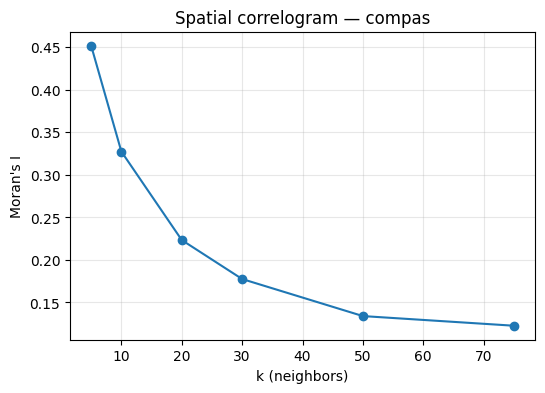

In [14]:
from analysis.spatial import spatial_correlogram

corr_df = spatial_correlogram(
    v=v_rep,
    X=X_rep,
    k_values=(5, 10, 20, 30, 50, 75),
    permutations=999,
    seed=42,
)

display(corr_df)

plt.figure(figsize=(6, 4))
plt.plot(corr_df["k"], corr_df["moran_i"], marker="o")
plt.xlabel("k (neighbors)")
plt.ylabel("Moran's I")
plt.title(f"Spatial correlogram — {DATASET}")
plt.grid(alpha=0.3)
plt.show()

## Family-wise Moran/LISA comparison

Compute Moran's I and HH counts for per-family Rashomon sets (top-K=25 per family) and compare to global. This helps determine whether multiplicity hotspots originate from inter-family or intra-family diversity.

Global mean HH = 81.0, Global mean Moran's I = 0.1908



,family,moran_mean,moran_std,n_hh_mean,n_hh_std,mean_var_mean,mean_var_std
0,GBM,0.241534,0.057654,85.6,22.984052,0.001111,0.000255
1,LogReg,0.118564,0.121270,38.3,49.535733,0.000057,0.000138
2,MLP,0.430351,0.059692,245.7,35.302030,0.001326,0.000110
3,RF,0.158262,0.044086,99.5,29.930475,0.003209,0.000236
4,kNN,0.090822,0.017132,76.9,35.619751,0.010571,0.001428


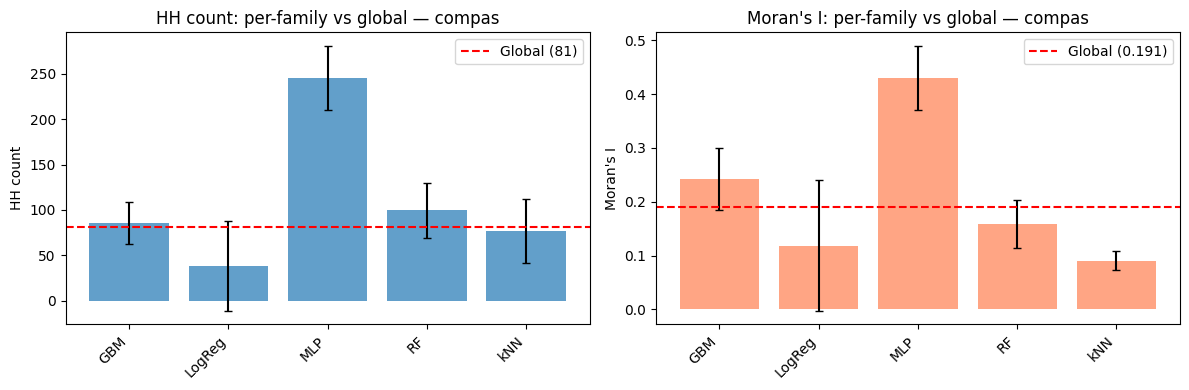

In [15]:
from analysis.run_analysis import run_spatial_per_family, select_rashomon_global, pointwise_variance, spatial_analysis

fam_records = []
glob_records = []

for run_dir in run_dirs:
    seed_name = run_dir.name
    X_test = get_transformed_test_features(run_dir, DATASET)

    # Per-family spatial
    fam_results = run_spatial_per_family(run_dir, X_test, K=K, k=k_nn, seed=42)
    for family, res in fam_results.items():
        fam_records.append({
            "run": seed_name, "family": family,
            "moran_i": res["moran_i"], "n_hh": res["n_hh"],
            "mean_variance": res["mean_variance"],
        })

    # Global spatial for comparison
    idx_g = select_rashomon_global(run_dir, K=K)
    P_test = load_P_test(run_dir)
    v_g = pointwise_variance(P_test[idx_g])
    sp_g = spatial_analysis(v_g, X_test, k=k_nn, seed=42)
    glob_records.append({
        "run": seed_name,
        "moran_i": sp_g["moran_i"], "n_hh": int(sp_g["HH_mask"].sum()),
        "mean_variance": float(v_g.mean()),
    })

fam_df = pd.DataFrame(fam_records)
glob_df = pd.DataFrame(glob_records)

# Aggregate
fam_agg = fam_df.groupby("family").agg(
    moran_mean=("moran_i", "mean"), moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"), n_hh_std=("n_hh", "std"),
    mean_var_mean=("mean_variance", "mean"), mean_var_std=("mean_variance", "std"),
).reset_index()

glob_mean_hh = glob_df["n_hh"].mean()
glob_mean_moran = glob_df["moran_i"].mean()

print(f"Global mean HH = {glob_mean_hh:.1f}, Global mean Moran's I = {glob_mean_moran:.4f}")
print()
display(fam_agg)

# Bar plot: HH count per family vs global
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
families = fam_agg["family"].values
x = range(len(families))

ax1.bar(x, fam_agg["n_hh_mean"], yerr=fam_agg["n_hh_std"], capsize=3, alpha=0.7)
ax1.axhline(glob_mean_hh, color="red", ls="--", label=f"Global ({glob_mean_hh:.0f})")
ax1.set_xticks(list(x)); ax1.set_xticklabels(families, rotation=45, ha="right")
ax1.set_ylabel("HH count"); ax1.set_title(f"HH count: per-family vs global — {DATASET}")
ax1.legend()

ax2.bar(x, fam_agg["moran_mean"], yerr=fam_agg["moran_std"], capsize=3, alpha=0.7, color="coral")
ax2.axhline(glob_mean_moran, color="red", ls="--", label=f"Global ({glob_mean_moran:.3f})")
ax2.set_xticks(list(x)); ax2.set_xticklabels(families, rotation=45, ha="right")
ax2.set_ylabel("Moran's I"); ax2.set_title(f"Moran's I: per-family vs global — {DATASET}")
ax2.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / f"family_vs_global_spatial_{DATASET}.pdf", bbox_inches="tight")
plt.show()

## Variance vs Conflict hotspots

Side-by-side PCA plots comparing variance-based HH and conflict-based HH for the representative run. Also shows overlap vs XOR (symmetric difference) and reports Jaccard overlap.

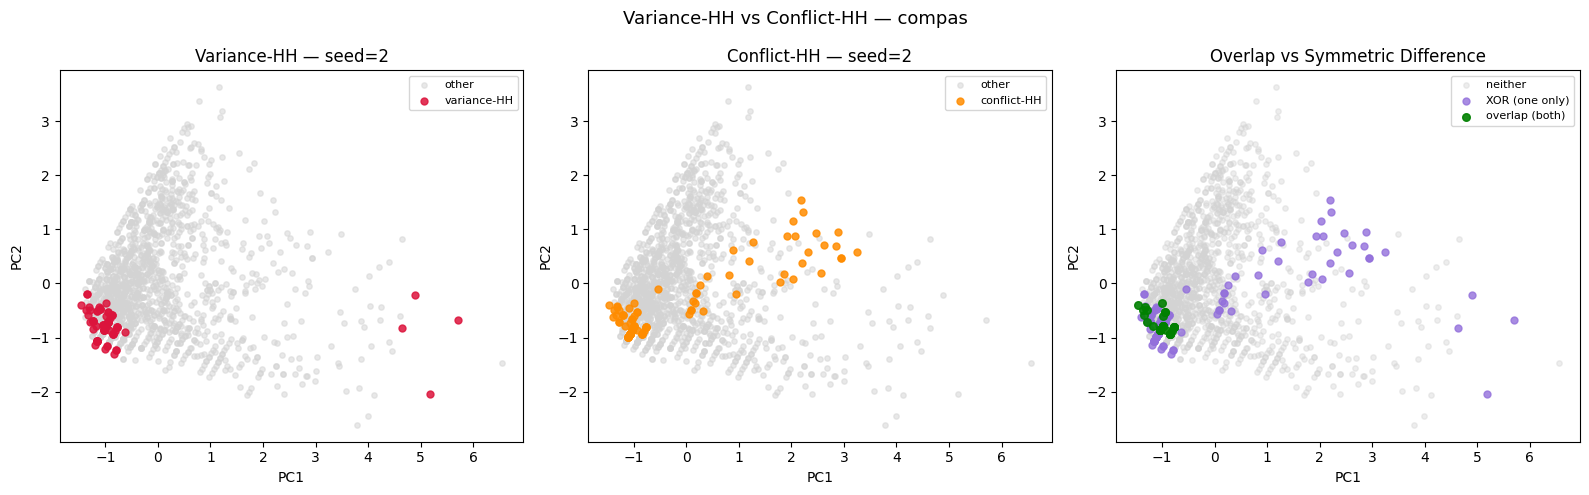

Variance-HH vs Conflict-HH Jaccard for seed=2:
  |var-HH| = 81, |conf-HH| = 96
  |intersection| = 31, |union| = 146
  Jaccard = 0.2123


In [16]:
# Conflict-HH vs variance-HH for the representative run
r_rep = spatial_by_run[rep_idx]
var_hh = r_rep["HH_mask"]
conf_hh = r_rep.get("conflict_HH_mask", np.zeros(len(var_hh), dtype=bool))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: variance-HH
axes[0].scatter(coords[~var_hh, 0], coords[~var_hh, 1], c="lightgray", s=15, alpha=0.5, label="other")
axes[0].scatter(coords[var_hh, 0], coords[var_hh, 1], c="crimson", s=25, alpha=0.85, label="variance-HH")
axes[0].set_title(f"Variance-HH — {r_rep['run_dir']}")
axes[0].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[0].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[0].legend(fontsize=8)

# Panel B: conflict-HH
axes[1].scatter(coords[~conf_hh, 0], coords[~conf_hh, 1], c="lightgray", s=15, alpha=0.5, label="other")
axes[1].scatter(coords[conf_hh, 0], coords[conf_hh, 1], c="darkorange", s=25, alpha=0.85, label="conflict-HH")
axes[1].set_title(f"Conflict-HH — {r_rep['run_dir']}")
axes[1].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[1].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[1].legend(fontsize=8)

# Panel C: overlap vs XOR
overlap = var_hh & conf_hh
xor = var_hh ^ conf_hh
rest = ~(var_hh | conf_hh)
axes[2].scatter(coords[rest, 0], coords[rest, 1], c="lightgray", s=15, alpha=0.4, label="neither")
axes[2].scatter(coords[xor, 0], coords[xor, 1], c="mediumpurple", s=25, alpha=0.8, label="XOR (one only)")
axes[2].scatter(coords[overlap, 0], coords[overlap, 1], c="green", s=30, alpha=0.9, label="overlap (both)")
axes[2].set_title("Overlap vs Symmetric Difference")
axes[2].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[2].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[2].legend(fontsize=8)

fig.suptitle(f"Variance-HH vs Conflict-HH — {DATASET}", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / f"var_vs_conflict_hh_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Jaccard overlap
union_count = int(np.sum(var_hh | conf_hh))
inter_count = int(np.sum(var_hh & conf_hh))
J_vc = inter_count / union_count if union_count > 0 else 0.0
print(f"Variance-HH vs Conflict-HH Jaccard for {r_rep['run_dir']}:")
print(f"  |var-HH| = {int(np.sum(var_hh))}, |conf-HH| = {int(np.sum(conf_hh))}")
print(f"  |intersection| = {inter_count}, |union| = {union_count}")
print(f"  Jaccard = {J_vc:.4f}")

## HH overlap stability

Pairwise Jaccard overlaps between HH masks across all seed pairs for both variance-HH and conflict-HH. Also cross Jaccard (variance-HH vs conflict-HH) per seed.

C:\Users\dejvi\AppData\Local\Temp\ipykernel_19732\2167941155.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([off_diag_var, off_diag_conf], labels=["Variance-HH", "Conflict-HH"],


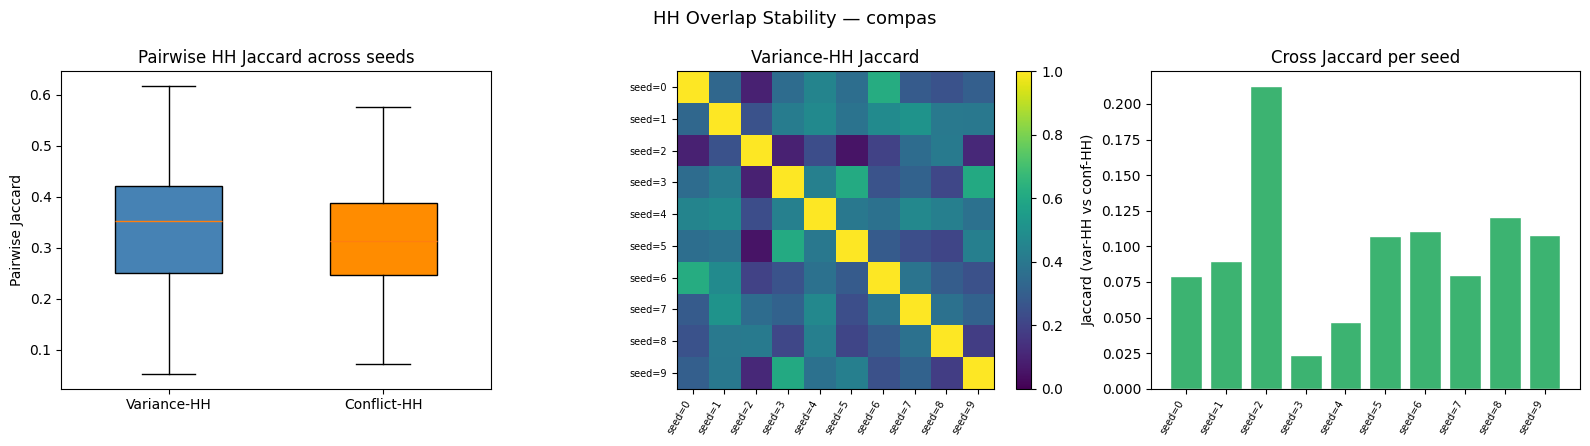

Variance-HH pairwise Jaccard: mean=0.339, std=0.131
Conflict-HH pairwise Jaccard: mean=0.312, std=0.115
Cross Jaccard (var vs conf) per seed: mean=0.098, std=0.048


In [17]:
from analysis.stability import hh_jaccard_matrix

# Variance-HH pairwise Jaccard (already computed as J in cell 6)
var_hh_masks = [r["HH_mask"] for r in spatial_by_run]
J_var = hh_jaccard_matrix(var_hh_masks)

# Conflict-HH pairwise Jaccard
conf_hh_masks = [r.get("conflict_HH_mask", np.zeros(len(r["HH_mask"]), dtype=bool)) for r in spatial_by_run]
J_conf = hh_jaccard_matrix(conf_hh_masks)

# Cross: variance-HH vs conflict-HH per seed
cross_jaccards = []
for r in spatial_by_run:
    v = r["HH_mask"]
    c = r.get("conflict_HH_mask", np.zeros(len(v), dtype=bool))
    union_c = int(np.sum(v | c))
    j = int(np.sum(v & c)) / union_c if union_c > 0 else 0.0
    cross_jaccards.append(j)

n_seeds = len(spatial_by_run)
run_labels = [r["run_dir"] for r in spatial_by_run]

# Extract off-diagonal values
off_diag_var = J_var[~np.eye(n_seeds, dtype=bool)]
off_diag_conf = J_conf[~np.eye(n_seeds, dtype=bool)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# A) Boxplot of pairwise Jaccard (variance-HH and conflict-HH)
bp = axes[0].boxplot([off_diag_var, off_diag_conf], labels=["Variance-HH", "Conflict-HH"],
                     patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("darkorange")
axes[0].set_ylabel("Pairwise Jaccard")
axes[0].set_title("Pairwise HH Jaccard across seeds")

# B) Jaccard heatmap for variance-HH
im1 = axes[1].imshow(J_var, cmap="viridis", vmin=0, vmax=1)
axes[1].set_xticks(range(n_seeds)); axes[1].set_xticklabels(run_labels, rotation=60, ha="right", fontsize=7)
axes[1].set_yticks(range(n_seeds)); axes[1].set_yticklabels(run_labels, fontsize=7)
axes[1].set_title("Variance-HH Jaccard")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# C) Cross Jaccard per seed
axes[2].bar(range(n_seeds), cross_jaccards, color="mediumseagreen", edgecolor="white")
axes[2].set_xticks(range(n_seeds))
axes[2].set_xticklabels(run_labels, rotation=60, ha="right", fontsize=7)
axes[2].set_ylabel("Jaccard (var-HH vs conf-HH)")
axes[2].set_title("Cross Jaccard per seed")

fig.suptitle(f"HH Overlap Stability — {DATASET}", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / f"hh_jaccard_distributions_{DATASET}.pdf", bbox_inches="tight")
plt.show()

print(f"Variance-HH pairwise Jaccard: mean={off_diag_var.mean():.3f}, std={off_diag_var.std():.3f}")
print(f"Conflict-HH pairwise Jaccard: mean={off_diag_conf.mean():.3f}, std={off_diag_conf.std():.3f}")
print(f"Cross Jaccard (var vs conf) per seed: mean={np.mean(cross_jaccards):.3f}, std={np.std(cross_jaccards):.3f}")

## Region-level stability metrics

Pointwise Jaccard is low, but that doesn't mean the *regions* are unstable. We compute three complementary region-level metrics:
1. **HH frequency mass** — proportion of total HH-frequency concentrated in the top component(s)
2. **Component centroid stability** — distance between centroids of the largest HH component across seeds (in PCA space)
3. **Smoothed overlap** — Jaccard after 1-hop neighborhood dilation (treats HH as regions, not exact points)

In [18]:
from sklearn.decomposition import PCA
from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.stability import (
    hh_frequency_mass,
    component_centroid_stability,
    smoothed_overlap,
    summarize_region_stability,
)
from analysis.spatial import extract_hh_components
DATASETS = ['compas', 'german', 'adult']

# Defaults if this cell runs before the cell that sets RESULTS_DIR, K
if 'RESULTS_DIR' not in dir() or not isinstance(RESULTS_DIR if 'RESULTS_DIR' in dir() else None, Path):
    try:
        from thesis_layout import RAW_RESULTS as _RR
        RESULTS_DIR = _RR
    except Exception:
        RESULTS_DIR = Path("results")
if 'K' not in dir():
    K = 25

# Build all_runs if not already defined (avoids NameError when cell run alone)
all_runs = globals().get("all_runs", None)
if all_runs is None:
    all_runs = []
    for _ds in DATASETS:
        dataset_dir = RESULTS_DIR / _ds
        run_dirs_ds = _get_run_dirs(dataset_dir)
        if not run_dirs_ds:
            continue
        for run_dir in run_dirs_ds:
            n_cand = len(load_meta(run_dir))
            K_actual = min(K, n_cand)
            X_test = get_transformed_test_features(run_dir, _ds)
            res = run_spatial(run_dir, X_test, K=K_actual, k=K_NN_BY_DATASET[_ds], seed=42)
            r = dict(res)
            r["dataset"] = _ds
            r["X_test"] = X_test
            all_runs.append(r)

for ds in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Region-level stability: {ds}")
    print(f"{'='*60}")

    ds_runs = [r for r in all_runs if r["dataset"] == ds]
    if not ds_runs:
        print("  (no runs)")
        continue

    hh_masks_ds = [r["HH_mask"] for r in ds_runs]
    freq = hh_selection_frequency(hh_masks_ds)

    X_test_first = ds_runs[0]["X_test"]
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_test_first)

    components_list = []
    for r in ds_runs:
        lisa_df = pd.DataFrame({"cluster": np.where(r["HH_mask"], "HH", "NS")})
        W_sparse = r["W"].to_sparse() if hasattr(r["W"], "to_sparse") else r["W"].sparse
        _, comps = extract_hh_components(lisa_df, W_sparse, min_size=5)
        components_list.append(comps)

    W_sparse = ds_runs[0]["W"].to_sparse() if hasattr(ds_runs[0]["W"], "to_sparse") else ds_runs[0]["W"].sparse
    summary = summarize_region_stability(
        hh_masks_ds,
        components_list,
        X_pca,
        W_sparse,
        dilation_hops=1,
    )

    print(f"\n  Point-level stability:")
    print(f"    Mean Jaccard (pointwise):        {summary['mean_jaccard']:.4f}")
    print(f"    Min Jaccard:                     {summary['min_jaccard']:.4f}")
    print(f"    Max Jaccard:                     {summary['max_jaccard']:.4f}")
    print(f"\n  Region-level stability:")
    print(f"    Mean HH freq mass (top-1 comp):  {summary['mean_hh_frequency_mass_top1']:.4f}")
    print(f"    Mean centroid dist (PCA):         {summary['mean_centroid_dist']:.4f}")
    print(f"    Max centroid dist (PCA):          {summary['max_centroid_dist']:.4f}")
    print(f"    Seeds with components:            {summary['n_seeds_with_components']}")
    print(f"\n  Smoothed overlap (1-hop dilation):")
    print(f"    Mean smoothed Jaccard:           {summary['mean_smoothed_jaccard']:.4f}")
    print(f"    Min smoothed Jaccard:            {summary['min_smoothed_jaccard']:.4f}")
    print(f"    Max smoothed Jaccard:            {summary['max_smoothed_jaccard']:.4f}")

    improvement = summary['mean_smoothed_jaccard'] - summary['mean_jaccard']
    print(f"\n  Improvement (smoothed - pointwise): +{improvement:.4f}")


  Region-level stability: compas

  Point-level stability:
    Mean Jaccard (pointwise):        0.3395
    Min Jaccard:                     0.0522
    Max Jaccard:                     0.6176

  Region-level stability:
    Mean HH freq mass (top-1 comp):  0.3146
    Mean centroid dist (PCA):         2.0494
    Max centroid dist (PCA):          5.0566
    Seeds with components:            10

  Smoothed overlap (1-hop dilation):
    Mean smoothed Jaccard:           0.4363
    Min smoothed Jaccard:            0.0998
    Max smoothed Jaccard:            0.6750

  Improvement (smoothed - pointwise): +0.0969

  Region-level stability: german

  Point-level stability:
    Mean Jaccard (pointwise):        0.2281
    Min Jaccard:                     0.0000
    Max Jaccard:                     1.0000

  Region-level stability:
    Mean HH freq mass (top-1 comp):  0.3333
    Mean centroid dist (PCA):         0.0000
    Max centroid dist (PCA):          0.0000
    Seeds with components:          

## Regionality metrics of HH hotspots

To summarize the structure of multiplicity regions, we compute regionality metrics based on connected components of HH hotspots.

These metrics describe whether hotspots form a few large coherent regions or many small fragmented clusters.

component_sizes: [26, 6, 8]


,n_hh_points,n_components,largest_component_size,mean_component_size,median_component_size,share_in_largest_component,fragmentation_index
0,43,3,26,13.333333,8.0,0.604651,0.069767


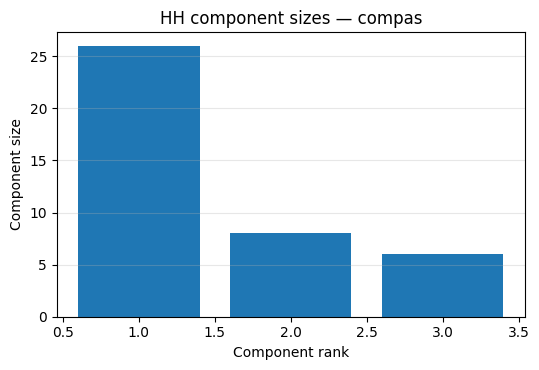

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# components is expected to be a dict: component_id -> array of member indices
# HH_mask is the boolean mask of HH hotspot points for the representative run

if not isinstance(components, dict):
    raise TypeError(f"`components` should be a dict, got {type(components)}")

component_sizes = (
    np.array([len(v) for v in components.values()], dtype=int)
    if len(components) > 0
    else np.array([], dtype=int)
)

n_hh_points = int(HH_mask.sum())

regionality_df = pd.DataFrame([{
    "n_hh_points": n_hh_points,
    "n_components": int(len(component_sizes)),
    "largest_component_size": int(component_sizes.max()) if len(component_sizes) else 0,
    "mean_component_size": float(component_sizes.mean()) if len(component_sizes) else 0.0,
    "median_component_size": float(np.median(component_sizes)) if len(component_sizes) else 0.0,
    "share_in_largest_component": (
        float(component_sizes.max() / n_hh_points)
        if n_hh_points > 0 and len(component_sizes)
        else 0.0
    ),
    "fragmentation_index": (
        float(len(component_sizes) / n_hh_points)
        if n_hh_points > 0
        else 0.0
    ),
}])

print("component_sizes:", component_sizes.tolist())
display(regionality_df)

# optional bar plot of component sizes
if len(component_sizes) > 0:
    sizes_sorted = np.sort(component_sizes)[::-1]

    plt.figure(figsize=(5.5, 3.8))
    plt.bar(range(1, len(sizes_sorted) + 1), sizes_sorted)
    plt.xlabel("Component rank")
    plt.ylabel("Component size")
    plt.title(f"HH component sizes — {DATASET}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No HH components found.")